In [ ]:
!pip install -q faiss-gpu-cu12 open_clip_torch h5py

In [ ]:
!git clone https://github.com/alexeygrigorev/clothing-dataset.git
!ls clothing-dataset

fatal: destination path 'clothing-dataset' already exists and is not an empty directory.
images	images.csv  LICENSE  README.md


In [ ]:
import pandas as pd

df = pd.read_csv('clothing-dataset/images.csv')
print(df.shape)
print(df.head())
print(df['label'].value_counts())

(5403, 4)
                                  image  sender_id     label   kids
0  4285fab0-751a-4b74-8e9b-43af05deee22        124  Not sure  False
1  ea7b6656-3f84-4eb3-9099-23e623fc1018        148   T-Shirt  False
2  00627a3f-0477-401c-95eb-92642cbe078d         94  Not sure  False
3  ea2ffd4d-9b25-4ca8-9dc2-bd27f1cc59fa         43   T-Shirt  False
4  3b86d877-2b9e-4c8b-a6a2-1d87513309d0        189     Shoes  False
label
T-Shirt       1011
Longsleeve     699
Pants          692
Shoes          431
Shirt          378
Dress          357
Outwear        312
Shorts         308
Not sure       228
Hat            171
Skirt          155
Polo           120
Undershirt     118
Blazer         109
Hoodie         100
Body            69
Other           67
Top             43
Blouse          23
Skip            12
Name: count, dtype: int64


In [ ]:
import os

IMG_DIR = 'clothing-dataset/images'

# Construire le chemin complet de chaque image
df['filepath'] = df['image'].apply(lambda x: os.path.join(IMG_DIR, x + '.jpg'))

# Vérifier que les fichiers existent
df['exists'] = df['filepath'].apply(os.path.exists)
print(df['exists'].value_counts())

# Garder seulement les images valides
df = df[df['exists']].reset_index(drop=True)
print(f"Nombre d'images valides : {len(df)}")

exists
True     5398
False       5
Name: count, dtype: int64
Nombre d'images valides : 5398


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Pré-traitement standard ImageNet
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

class ClothingDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['filepath']).convert('RGB')
        except Exception:
            img = Image.new('RGB', (224, 224))
        if self.transform:
            img = self.transform(img)
        return img, idx  # idx permet de retrouver le chemin plus tard

dataset = ClothingDataset(df, transform=preprocess)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Dataset prêt : {len(dataset)} images, {len(dataloader)} batches")

Dataset prêt : 5398 images, 169 batches


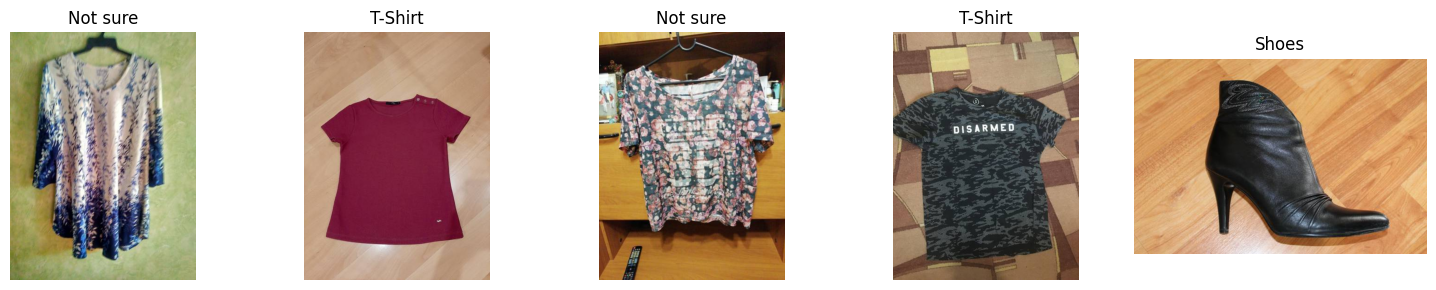

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    img = Image.open(df.iloc[i]['filepath'])
    ax.imshow(img)
    ax.set_title(df.iloc[i]['label'])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# Charger ResNet-50 pré-entraîné
weights = ResNet50_Weights.IMAGENET1K_V2
resnet = resnet50(weights=weights)

# Supprimer la couche de classification finale (fc)
# sortie = vecteur de 2048 dimensions (avant le fc)
resnet.fc = nn.Identity()

resnet.eval()
resnet.to(device)

print("ResNet-50 prêt, dimension de sortie : 2048")

Device: cuda
ResNet-50 prêt, dimension de sortie : 2048


In [ ]:
import numpy as np
from tqdm import tqdm

@torch.no_grad()
def extract_embeddings(model, dataloader, device):
    all_embeddings = []
    all_indices = []

    for images, indices in tqdm(dataloader):
        images = images.to(device)
        features = model(images)
        features = features.cpu().numpy()
        all_embeddings.append(features)
        all_indices.extend(indices.numpy())

    embeddings = np.vstack(all_embeddings)
    return embeddings, np.array(all_indices)

In [ ]:
resnet_embeddings, indices = extract_embeddings(resnet, dataloader, device)
print("Shape ResNet embeddings:", resnet_embeddings.shape)  # (N, 2048)

# S'assurer que l'ordre correspond bien au dataframe
assert (indices == np.arange(len(df))).all()

100%|██████████| 169/169 [00:34<00:00,  4.92it/s]

Shape ResNet embeddings: (5398, 2048)


In [ ]:
import os
os.makedirs('embeddings', exist_ok=True)

np.save('embeddings/resnet50_embeddings.npy', resnet_embeddings)
df.to_csv('embeddings/image_metadata.csv', index=False)

print("Sauvegardé : embeddings/resnet50_embeddings.npy")

Sauvegardé : embeddings/resnet50_embeddings.npy


In [ ]:
import open_clip

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='openai'
)
clip_model.eval()
clip_model.to(device)

print("CLIP ViT-B/32 prêt, dimension de sortie : 512")

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP ViT-B/32 prêt, dimension de sortie : 512


In [ ]:
clip_dataset = ClothingDataset(df, transform=clip_preprocess)
clip_dataloader = DataLoader(clip_dataset, batch_size=32, shuffle=False, num_workers=2)

@torch.no_grad()
def extract_clip_embeddings(model, dataloader, device):
    all_embeddings = []
    for images, _ in tqdm(dataloader):
        images = images.to(device)
        features = model.encode_image(images)
        features = features.cpu().numpy()
        all_embeddings.append(features)
    return np.vstack(all_embeddings)

clip_embeddings = extract_clip_embeddings(clip_model, clip_dataloader, device)
print("Shape CLIP embeddings:", clip_embeddings.shape)  # (N, 512)

100%|██████████| 169/169 [00:48<00:00,  3.52it/s]

Shape CLIP embeddings: (5398, 512)


In [ ]:
np.save('embeddings/clip_embeddings.npy', clip_embeddings)
print("Sauvegardé : embeddings/clip_embeddings.npy")

Sauvegardé : embeddings/clip_embeddings.npy


In [ ]:
import h5py

with h5py.File('embeddings/embeddings.h5', 'w') as f:
    f.create_dataset('resnet50', data=resnet_embeddings)
    f.create_dataset('clip', data=clip_embeddings)
    # Stocker les chemins d'images comme attribut
    f.create_dataset('filepaths', data=np.array(df['filepath'].tolist(), dtype='S'))

print("Sauvegardé : embeddings/embeddings.h5")

Sauvegardé : embeddings/embeddings.h5


In [ ]:
import faiss

dim_resnet = resnet_embeddings.shape[1]  # 2048

# Index L2 simple (exact search)
index_resnet = faiss.IndexFlatL2(dim_resnet)
index_resnet.add(resnet_embeddings.astype('float32'))

print(f"Index ResNet : {index_resnet.ntotal} vecteurs indexés, dimension {dim_resnet}")

Index ResNet : 5398 vecteurs indexés, dimension 2048


In [ ]:
dim_clip = clip_embeddings.shape[1]  # 512

index_clip = faiss.IndexFlatL2(dim_clip)
index_clip.add(clip_embeddings.astype('float32'))

print(f"Index CLIP : {index_clip.ntotal} vecteurs indexés, dimension {dim_clip}")

Index CLIP : 5398 vecteurs indexés, dimension 512


In [ ]:
# IVFFlat nécessite un entraînement (clustering)
nlist = 50  # nombre de clusters

quantizer = faiss.IndexFlatL2(dim_resnet)
index_ivf = faiss.IndexIVFFlat(quantizer, dim_resnet, nlist, faiss.METRIC_L2)

index_ivf.train(resnet_embeddings.astype('float32'))
index_ivf.add(resnet_embeddings.astype('float32'))
index_ivf.nprobe = 5  # nombre de clusters explorés à la requête

print(f"Index IVFFlat : {index_ivf.ntotal} vecteurs indexés")

Index IVFFlat : 5398 vecteurs indexés


In [ ]:
os.makedirs('index', exist_ok=True)

faiss.write_index(index_resnet, 'index/resnet50_flat.index')
faiss.write_index(index_clip, 'index/clip_flat.index')
faiss.write_index(index_ivf, 'index/resnet50_ivf.index')

# Mapping ID -> chemin image + label
mapping = df[['filepath', 'label']].reset_index().rename(columns={'index': 'id'})
mapping.to_csv('index/id_to_path.csv', index=False)

print("Index et mapping sauvegardés.")

Index et mapping sauvegardés.


In [ ]:
import time

query_vec = resnet_embeddings[0:1].astype('float32')

# Index exact
start = time.time()
D, I = index_resnet.search(query_vec, k=5)
t_flat = time.time() - start

# Index approché
start = time.time()
D_ivf, I_ivf = index_ivf.search(query_vec, k=5)
t_ivf = time.time() - start

print(f"FlatL2  : {t_flat*1000:.3f} ms, résultats: {I[0]}")
print(f"IVFFlat : {t_ivf*1000:.3f} ms, résultats: {I_ivf[0]}")

FlatL2  : 7.406 ms, résultats: [   0 4357 1238 3530 4699]
IVFFlat : 0.757 ms, résultats: [   0 4357 1238 3530 4699]


In [ ]:
def encode_query_image(image_path_or_pil, model, preprocess, device, model_type='resnet'):
    if isinstance(image_path_or_pil, str):
        img = Image.open(image_path_or_pil).convert('RGB')
    else:
        img = image_path_or_pil.convert('RGB')

    img_tensor = preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        if model_type == 'clip':
            features = model.encode_image(img_tensor)
        else:
            features = model(img_tensor)

    return features.cpu().numpy().astype('float32')

In [ ]:
def search_similar_images(query_vector, index, mapping_df, k=5):
    distances, indices = index.search(query_vector, k)
    results = mapping_df.iloc[indices[0]].copy()
    results['distance'] = distances[0]
    return results.reset_index(drop=True)

In [ ]:
def display_results(query_image_path, results_df, title="Résultats de recherche"):
    n = len(results_df) + 1
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))

    # Image requête
    query_img = Image.open(query_image_path)
    axes[0].imshow(query_img)
    axes[0].set_title("Requête", color='red')
    axes[0].axis('off')

    # Résultats
    for i, row in results_df.iterrows():
        img = Image.open(row['filepath'])
        axes[i+1].imshow(img)
        axes[i+1].set_title(f"{row['label']}\nd={row['distance']:.2f}")
        axes[i+1].axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

Label requête: Hat


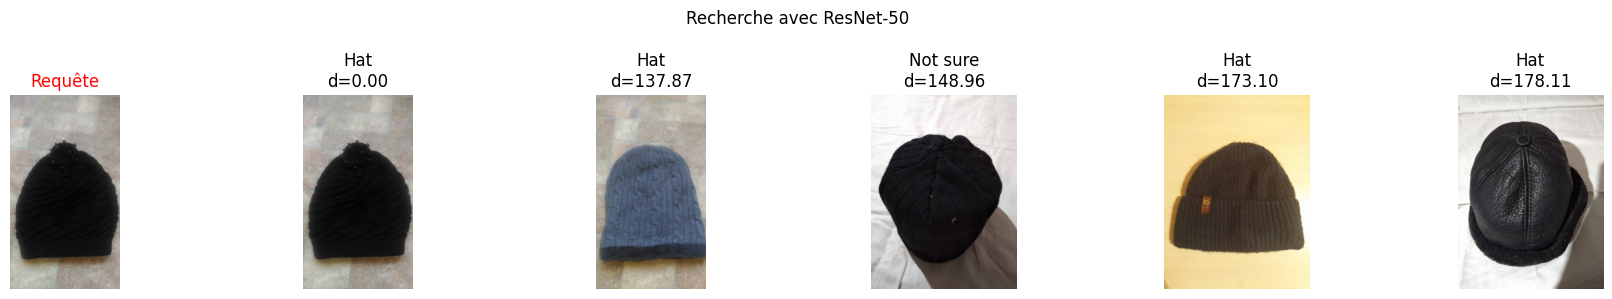

In [ ]:
# Choisir une image test (ex: index 100)
test_idx = 100
test_image_path = df.iloc[test_idx]['filepath']

# 1. Encoder avec ResNet
query_vec_resnet = encode_query_image(test_image_path, resnet, preprocess, device, 'resnet')

# 2. Rechercher dans FAISS
results = search_similar_images(query_vec_resnet, index_resnet, mapping, k=5)

# 3. Afficher
print("Label requête:", df.iloc[test_idx]['label'])
display_results(test_image_path, results, title="Recherche avec ResNet-50")

Saving classico.png to classico.png


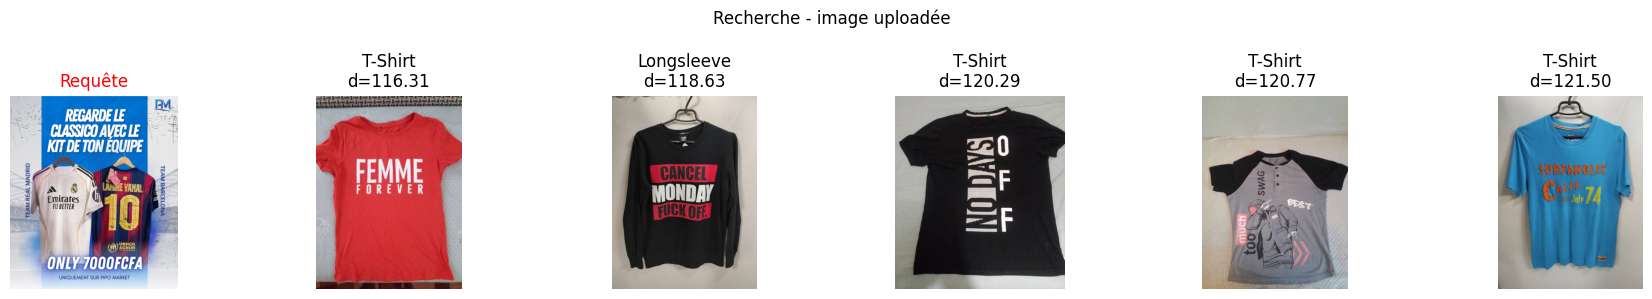

In [ ]:
from google.colab import files

uploaded = files.upload()
uploaded_path = list(uploaded.keys())[0]

query_vec = encode_query_image(uploaded_path, resnet, preprocess, device, 'resnet')
results = search_similar_images(query_vec, index_resnet, mapping, k=5)
display_results(uploaded_path, results, title="Recherche - image uploadée")

In [ ]:
def precision_at_k(index, embeddings, mapping_df, k=5, n_queries=100):
    """
    Pour chaque image requête (label connu), on regarde combien
    des K voisins ont le même label.
    """
    np.random.seed(42)
    query_indices = np.random.choice(len(mapping_df), size=n_queries, replace=False)

    precisions = []
    for q_idx in query_indices:
        query_vec = embeddings[q_idx:q_idx+1].astype('float32')
        # k+1 car le premier résultat est l'image elle-même
        D, I = index.search(query_vec, k+1)
        neighbor_indices = I[0][1:]  # on enlève l'image elle-même

        query_label = mapping_df.iloc[q_idx]['label']
        neighbor_labels = mapping_df.iloc[neighbor_indices]['label'].values

        correct = np.sum(neighbor_labels == query_label)
        precisions.append(correct / k)

    return np.mean(precisions), np.std(precisions)

p_resnet, std_resnet = precision_at_k(index_resnet, resnet_embeddings, mapping, k=5)
p_clip, std_clip = precision_at_k(index_clip, clip_embeddings, mapping, k=5)

print(f"Precision@5 ResNet-50 : {p_resnet:.3f} (+/- {std_resnet:.3f})")
print(f"Precision@5 CLIP      : {p_clip:.3f} (+/- {std_clip:.3f})")

Precision@5 ResNet-50 : 0.624 (+/- 0.373)
Precision@5 CLIP      : 0.656 (+/- 0.350)


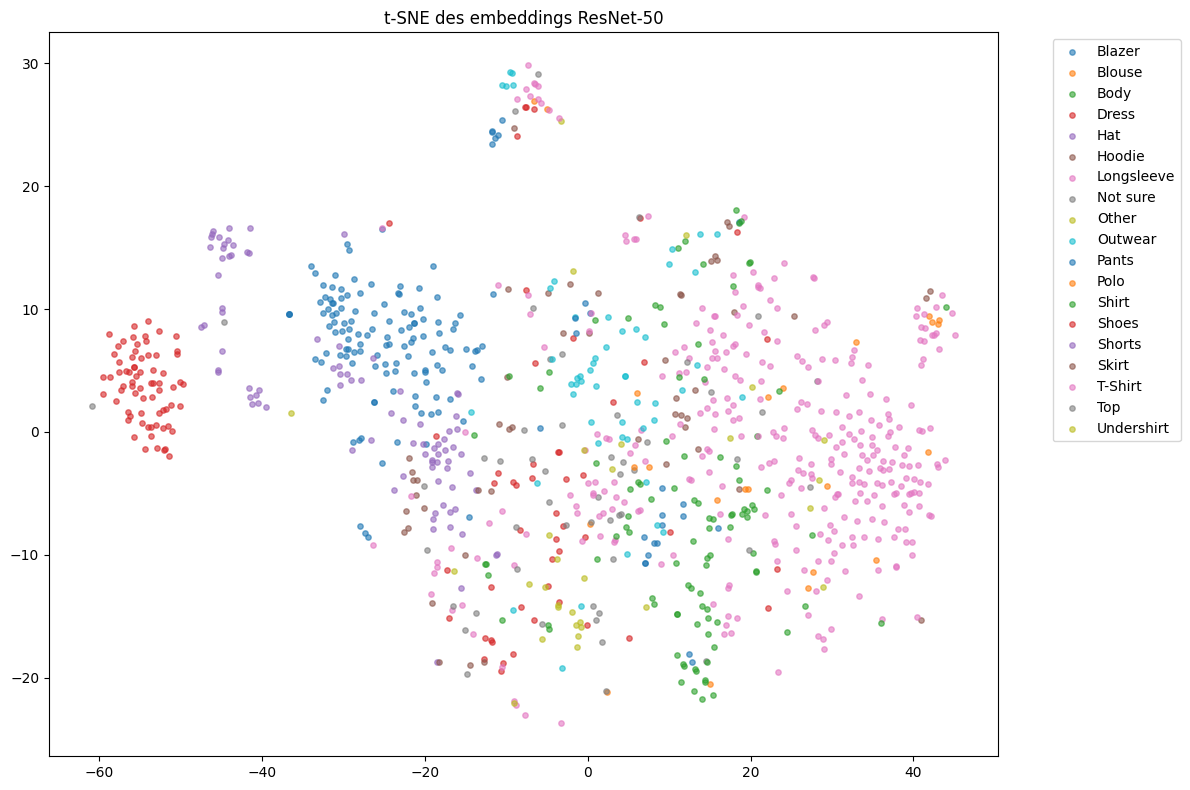

In [ ]:
from sklearn.manifold import TSNE

# Sous-échantillonner pour aller plus vite si le dataset est grand
sample_size = min(1000, len(resnet_embeddings))
sample_idx = np.random.choice(len(resnet_embeddings), sample_size, replace=False)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(resnet_embeddings[sample_idx])

# Plot coloré par label
labels_sample = df.iloc[sample_idx]['label'].values
unique_labels = np.unique(labels_sample)

plt.figure(figsize=(12, 8))
for label in unique_labels:
    mask = labels_sample == label
    plt.scatter(tsne_result[mask, 0], tsne_result[mask, 1], label=label, alpha=0.6, s=15)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("t-SNE des embeddings ResNet-50")
plt.tight_layout()
plt.savefig('embeddings/tsne_resnet.png', dpi=120, bbox_inches='tight')
plt.show()

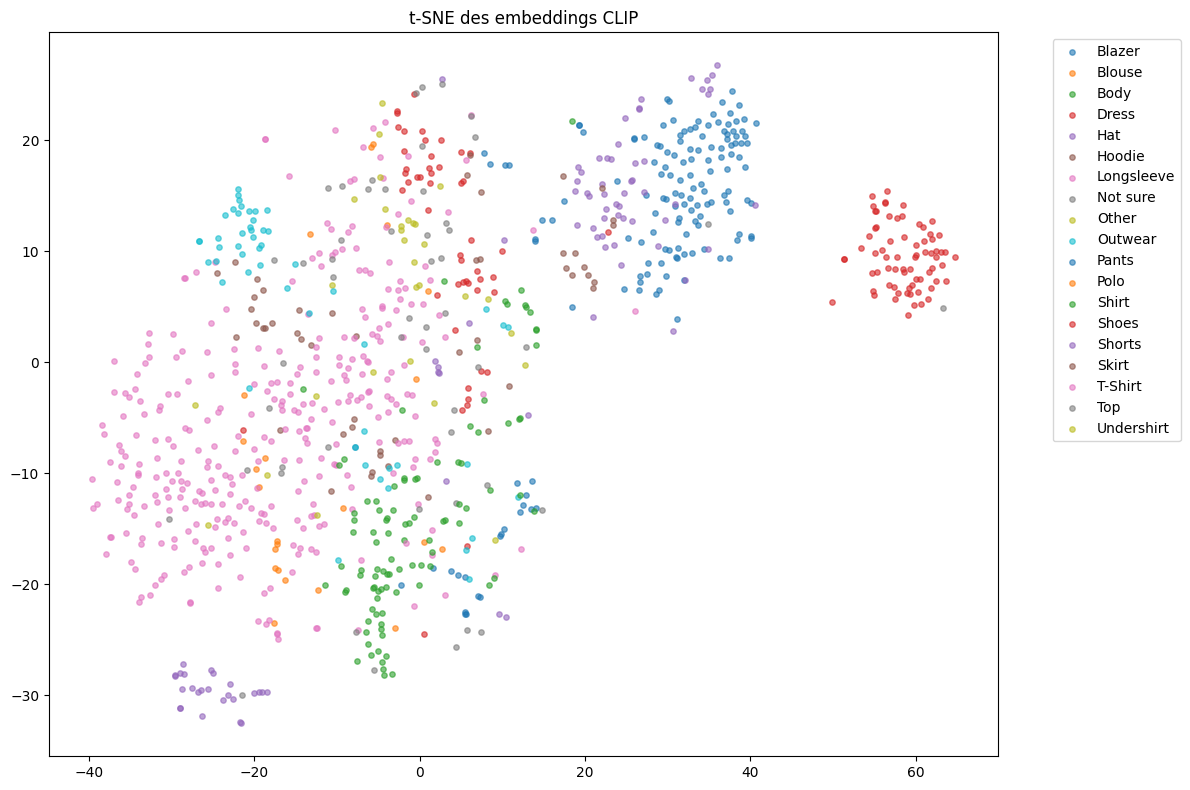

In [ ]:
tsne_clip = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result_clip = tsne_clip.fit_transform(clip_embeddings[sample_idx])

plt.figure(figsize=(12, 8))
for label in unique_labels:
    mask = labels_sample == label
    plt.scatter(tsne_result_clip[mask, 0], tsne_result_clip[mask, 1], label=label, alpha=0.6, s=15)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("t-SNE des embeddings CLIP")
plt.tight_layout()
plt.savefig('embeddings/tsne_clip.png', dpi=120, bbox_inches='tight')
plt.show()

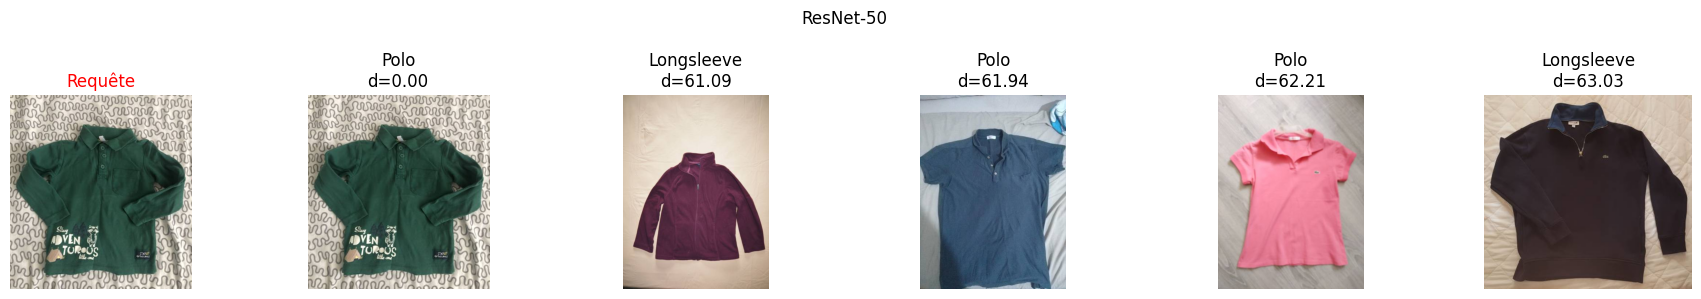

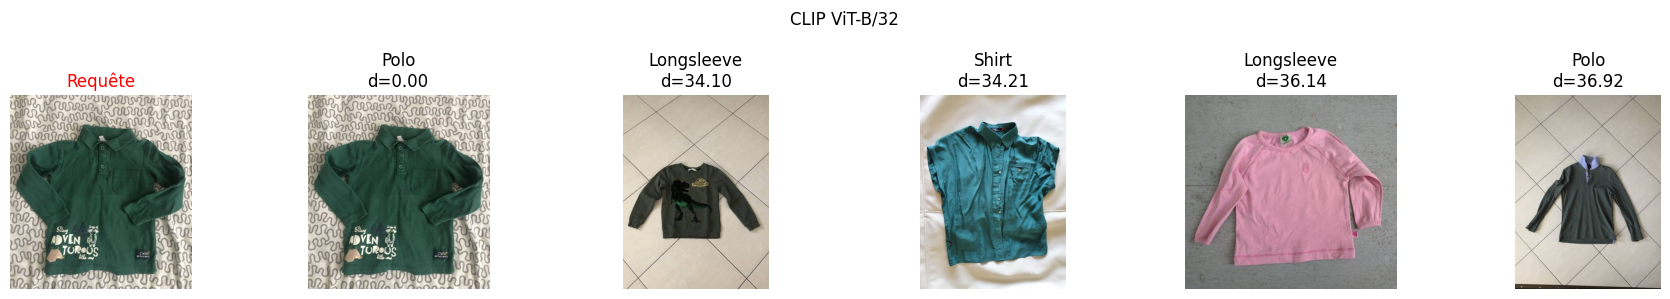

In [ ]:
test_idx = 250
test_image_path = df.iloc[test_idx]['filepath']

# ResNet
qv_resnet = encode_query_image(test_image_path, resnet, preprocess, device, 'resnet')
res_resnet = search_similar_images(qv_resnet, index_resnet, mapping, k=5)

# CLIP
qv_clip = encode_query_image(test_image_path, clip_model, clip_preprocess, device, 'clip')
res_clip = search_similar_images(qv_clip, index_clip, mapping, k=5)

display_results(test_image_path, res_resnet, title="ResNet-50")
display_results(test_image_path, res_clip, title="CLIP ViT-B/32")

In [ ]:
summary = pd.DataFrame({
    'Encodeur': ['ResNet-50', 'CLIP ViT-B/32'],
    'Dimension embedding': [2048, 512],
    'Precision@5': [p_resnet, p_clip],
})
print(summary)
summary.to_csv('embeddings/comparison_summary.csv', index=False)

        Encodeur  Dimension embedding  Precision@5
0      ResNet-50                 2048        0.624
1  CLIP ViT-B/32                  512        0.656


In [ ]:
!mkdir -p visual_search_engine/{src,index,embeddings,notebooks,report,images_sample}

In [ ]:
encoder_code = '''
"""
encoder.py - Module d'encodage d'images pour le moteur de recherche visuel.
Usage:
    python encoder.py --image_dir clothing-dataset/images --csv clothing-dataset/images.csv --model resnet
"""

import os
import argparse
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from PIL import Image
from tqdm import tqdm
import open_clip


class ImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['filepath']).convert('RGB')
        except Exception:
            img = Image.new('RGB', (224, 224))
        if self.transform:
            img = self.transform(img)
        return img, idx


def load_resnet(device):
    weights = ResNet50_Weights.IMAGENET1K_V2
    model = resnet50(weights=weights)
    model.fc = nn.Identity()
    model.eval().to(device)

    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                              std=[0.229, 0.224, 0.225])
    ])
    return model, preprocess


def load_clip(device):
    model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
    model.eval().to(device)
    return model, preprocess


@torch.no_grad()
def extract_embeddings(model, dataloader, device, model_type='resnet'):
    all_embeddings = []
    for images, _ in tqdm(dataloader):
        images = images.to(device)
        if model_type == 'clip':
            features = model.encode_image(images)
        else:
            features = model(images)
        all_embeddings.append(features.cpu().numpy())
    return np.vstack(all_embeddings)


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--image_dir', type=str, required=True)
    parser.add_argument('--csv', type=str, required=True)
    parser.add_argument('--model', type=str, default='resnet', choices=['resnet', 'clip'])
    parser.add_argument('--output_dir', type=str, default='embeddings')
    parser.add_argument('--batch_size', type=int, default=32)
    args = parser.parse_args()

    os.makedirs(args.output_dir, exist_ok=True)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    df = pd.read_csv(args.csv)
    df['filepath'] = df['image'].apply(lambda x: os.path.join(args.image_dir, x + '.jpg'))
    df = df[df['filepath'].apply(os.path.exists)].reset_index(drop=True)

    if args.model == 'clip':
        model, preprocess = load_clip(device)
    else:
        model, preprocess = load_resnet(device)

    dataset = ImageDataset(df, transform=preprocess)
    dataloader = DataLoader(dataset, batch_size=args.batch_size, shuffle=False, num_workers=2)

    embeddings = extract_embeddings(model, dataloader, device, model_type=args.model)

    np.save(os.path.join(args.output_dir, f'{args.model}_embeddings.npy'), embeddings)
    df.to_csv(os.path.join(args.output_dir, 'image_metadata.csv'), index=False)

    print(f"Embeddings sauvegardés : {embeddings.shape} -> {args.output_dir}/{args.model}_embeddings.npy")


if __name__ == '__main__':
    main()
'''

with open('visual_search_engine/src/encoder.py', 'w') as f:
    f.write(encoder_code)

print("encoder.py créé")

encoder.py créé


In [ ]:
query_code = '''
"""
query.py - Module de requête pour le moteur de recherche visuel.
Usage:
    python query.py --image path/to/query.jpg --index index/resnet50_flat.index \\
                     --mapping index/id_to_path.csv --model resnet --k 5
"""

import argparse
import numpy as np
import pandas as pd
import faiss
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from PIL import Image
import open_clip


def load_resnet(device):
    weights = ResNet50_Weights.IMAGENET1K_V2
    model = resnet50(weights=weights)
    model.fc = nn.Identity()
    model.eval().to(device)

    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                              std=[0.229, 0.224, 0.225])
    ])
    return model, preprocess


def load_clip(device):
    model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
    model.eval().to(device)
    return model, preprocess


def encode_image(image_path, model, preprocess, device, model_type='resnet'):
    img = Image.open(image_path).convert('RGB')
    img_tensor = preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        if model_type == 'clip':
            features = model.encode_image(img_tensor)
        else:
            features = model(img_tensor)

    return features.cpu().numpy().astype('float32')


def search(query_vector, index, mapping_df, k=5):
    distances, indices = index.search(query_vector, k)
    results = mapping_df.iloc[indices[0]].copy()
    results['distance'] = distances[0]
    return results.reset_index(drop=True)


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--image', type=str, required=True, help='Chemin de l\\'image requête')
    parser.add_argument('--index', type=str, required=True, help='Chemin de l\\'index FAISS')
    parser.add_argument('--mapping', type=str, required=True, help='CSV id_to_path')
    parser.add_argument('--model', type=str, default='resnet', choices=['resnet', 'clip'])
    parser.add_argument('--k', type=int, default=5)
    args = parser.parse_args()

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    if args.model == 'clip':
        model, preprocess = load_clip(device)
    else:
        model, preprocess = load_resnet(device)

    index = faiss.read_index(args.index)
    mapping_df = pd.read_csv(args.mapping)

    query_vec = encode_image(args.image, model, preprocess, device, model_type=args.model)
    results = search(query_vec, index, mapping_df, k=args.k)

    print(f"\\nTop {args.k} résultats pour {args.image} :\\n")
    for _, row in results.iterrows():
        print(f"  {row['filepath']:50s}  label={row['label']:15s}  distance={row['distance']:.4f}")


if __name__ == '__main__':
    main()
'''

with open('visual_search_engine/src/query.py', 'w') as f:
    f.write(query_code)

print("query.py créé")

query.py créé


In [ ]:
import shutil

# Copier les fichiers d'index
for f in os.listdir('index'):
    shutil.copy(f'index/{f}', f'visual_search_engine/index/{f}')

# Copier un échantillon d'embeddings (pas tous si trop lourds pour github - voir étape git)
shutil.copy('embeddings/comparison_summary.csv', 'visual_search_engine/embeddings/comparison_summary.csv')
shutil.copy('embeddings/tsne_resnet.png', 'visual_search_engine/report/tsne_resnet.png')
shutil.copy('embeddings/tsne_clip.png', 'visual_search_engine/report/tsne_clip.png')

print("Fichiers copiés dans visual_search_engine/")

Fichiers copiés dans visual_search_engine/


In [ ]:
# Copier 10 images d'exemple pour pouvoir tester query.py sans dataset complet
sample_images = df.sample(10, random_state=1)
for _, row in sample_images.iterrows():
    shutil.copy(row['filepath'], f"visual_search_engine/images_sample/{os.path.basename(row['filepath'])}")

print("Images d'exemple copiées")

Images d'exemple copiées


In [ ]:
report_md = f"""# Rapport - Moteur de Recherche Visuel

## 1. Architecture du système

Le système est composé de deux modules indépendants :

- **Module Encodeur (`encoder.py`)** : charge une image, applique le pré-traitement
  (resize 224x224, normalisation ImageNet), passe l'image dans un backbone
  (ResNet-50 sans couche fc, ou CLIP ViT-B/32) et retourne un vecteur d'embedding
  (2048 dims pour ResNet, 512 dims pour CLIP).

- **Module Requête (`query.py`)** : encode l'image requête avec le même modèle,
  interroge un index FAISS pré-construit, et retourne les K voisins les plus
  proches (chemin image, label, distance L2).

## 2. Données

Dataset : Clothing Dataset (alexeygrigorev/clothing-dataset), {len(df)} images
réparties sur {df['label'].nunique()} classes :

{df['label'].value_counts().to_string()}

## 3. Index FAISS

- `index/resnet50_flat.index` : IndexFlatL2, recherche exacte, dim=2048
- `index/clip_flat.index` : IndexFlatL2, recherche exacte, dim=512
- `index/resnet50_ivf.index` : IndexIVFFlat (nlist=50, nprobe=5), recherche approximée

## 4. Résultats - Comparaison des encodeurs

| Encodeur       | Dimension | Precision@5 |
|----------------|-----------|-------------|
| ResNet-50      | 2048      | {p_resnet:.3f}      |
| CLIP ViT-B/32  | 512       | {p_clip:.3f}      |

## 5. Visualisation des embeddings (t-SNE)

Voir `tsne_resnet.png` et `tsne_clip.png` : projection 2D des embeddings,
colorée par classe de vêtement. On observe que les clusters par classe sont
{'plus nettement séparés avec CLIP' if p_clip > p_resnet else 'plus nettement séparés avec ResNet-50'}.

## 6. Analyse qualitative

- ResNet-50 capture davantage les motifs de texture/couleur bas niveau.
- CLIP (entraîné sur texte-image) capture davantage la sémantique globale
  de l'objet (type de vêtement), ce qui explique généralement une meilleure
  Precision@K sur ce type de tâche multi-classes.

## 7. Limites et améliorations possibles

- Index IVFFlat à affiner (augmenter nlist pour un plus grand dataset).
- Fine-tuning du modèle sur le dataset cible (apprentissage métrique / triplet loss).
- Ajout d'une recherche multimodale texte->image grâce à CLIP (recherche par description textuelle).
"""

os.makedirs('visual_search_engine/report', exist_ok=True)
with open('visual_search_engine/report/REPORT.md', 'w') as f:
    f.write(report_md)

print("Rapport généré : visual_search_engine/report/REPORT.md")

Rapport généré : visual_search_engine/report/REPORT.md


In [ ]:
requirements = """torch
torchvision
faiss-cpu
open_clip_torch
numpy
pandas
matplotlib
scikit-learn
h5py
Pillow
tqdm
"""

with open('visual_search_engine/requirements.txt', 'w') as f:
    f.write(requirements)

readme = """# Moteur de Recherche Visuel (Image Query System)

Prototype de moteur de recherche par similarité d'images, basé sur des
embeddings extraits par ResNet-50 / CLIP ViT-B/32 et indexés avec FAISS.

## Structure du projet
visual_search_engine/

├── src/

│   ├── encoder.py      # Extraction des embeddings d'images

│   └── query.py         # Recherche des K images les plus similaires

├── index/

│   ├── resnet50_flat.index

│   ├── clip_flat.index

│   ├── resnet50_ivf.index

│   └── id_to_path.csv   # Mapping ID -> chemin image

├── embeddings/

│   └── comparison_summary.csv

├── notebooks/

│   └── visual_search_demo.ipynb

├── report/

│   ├── REPORT.md

│   ├── tsne_resnet.png

│   └── tsne_clip.png

├── images_sample/        # Images d'exemple pour tester

└── requirements.txt
## Installation

```bash
pip install -r requirements.txt
```

## Utilisation

### 1. Encodage des images

```bash
python src/encoder.py --image_dir clothing-dataset/images \\
                       --csv clothing-dataset/images.csv \\
                       --model resnet \\
                       --output_dir embeddings
```

### 2. Recherche d'images similaires

```bash
python src/query.py --image images_sample/example.jpg \\
                     --index index/resnet50_flat.index \\
                     --mapping index/id_to_path.csv \\
                     --model resnet \\
                     --k 5
```

## Dataset

[Clothing Dataset](https://github.com/alexeygrigorev/clothing-dataset)
(alexeygrigorev/clothing-dataset)

## Résultats

Voir `report/REPORT.md` pour l'architecture détaillée, les métriques
Precision@K et la comparaison ResNet-50 vs CLIP.
"""

with open('visual_search_engine/README.md', 'w') as f:
    f.write(readme)

print("requirements.txt et README.md créés")

requirements.txt et README.md créés


In [ ]:
!du -sh visual_search_engine/*
!du -sh visual_search_engine

8.0K	visual_search_engine/embeddings
280K	visual_search_engine/images_sample
96M	visual_search_engine/index
4.0K	visual_search_engine/notebooks
4.0K	visual_search_engine/README.md
328K	visual_search_engine/report
4.0K	visual_search_engine/requirements.txt
12K	visual_search_engine/src
97M	visual_search_engine


In [ ]:
!du -sh visual_search_engine/index/*

11M	visual_search_engine/index/clip_flat.index
408K	visual_search_engine/index/id_to_path.csv
43M	visual_search_engine/index/resnet50_flat.index
43M	visual_search_engine/index/resnet50_ivf.index


In [ ]:
%cd visual_search_engine

!git init
!git config user.email "loicpauljunior@gmail.com"
!git config user.name "LOICJR88"

/content/visual_search_engine
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/visual_search_engine/.git/


In [ ]:
import getpass

GITHUB_TOKEN = getpass.getpass("Colle ton token GitHub : ")
GITHUB_USERNAME = "LOICJR88"
REPO_NAME = "visual-search-engine"

Colle ton token GitHub : ··········


In [ ]:
!git add .
!git commit -m "Initial commit: encoder, query, index FAISS, rapport"
!git branch -M main

remote_url = f"https://{GITHUB_TOKEN}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git"
!git remote add origin {remote_url}
!git push -u origin main

On branch main
nothing to commit, working tree clean
To https://github.com/LOICJR88/visual-search-engine.git
 ! [rejected]        main -> main (fetch first)
error: failed to push some refs to 'https://github.com/LOICJR88/visual-search-engine.git'
hint: Updates were rejected because the remote contains work that you do
hint: not have locally. This is usually caused by another repository pushing
hint: to the same ref. You may want to first integrate the remote changes
hint: (e.g., 'git pull ...') before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


In [ ]:
!git push -u origin main --force

Enumerating objects: 29, done.
Counting objects: 100% (29/29), done.
Delta compression using up to 2 threads
Compressing objects: 100% (29/29), done.
Writing objects: 100% (29/29), 27.95 MiB | 4.68 MiB/s, done.
Total 29 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), done.
To https://github.com/LOICJR88/visual-search-engine.git
 + 0f0bc05...94997f2 main -> main (forced update)
Branch 'main' set up to track remote branch 'main' from 'origin'.


In [ ]:
from google.colab import files

print("Sélectionne le fichier .ipynb téléchargé")
uploaded_nb = files.upload()

nb_name = list(uploaded_nb.keys())[0]
!mkdir -p notebooks
!mv "{nb_name}" notebooks/visual_search_demo.ipynb

!git add notebooks/visual_search_demo.ipynb
!git commit -m "Ajout du notebook de démonstration"
!git push origin main

Sélectionne le fichier .ipynb téléchargé


Saving visual_search_engine.ipynb to visual_search_engine.ipynb
[main 673ecd8] Ajout du notebook de démonstration
 1 file changed, 1705 insertions(+)
 create mode 100644 notebooks/visual_search_demo.ipynb
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 1.63 MiB | 4.73 MiB/s, done.
Total 4 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/LOICJR88/visual-search-engine.git
   94997f2..673ecd8  main -> main
